# Clase 4: Dinámica Interna 1


## Objetivos
1. El cúmulo como sistema estelar gravitacional (N-cuerpos).
2. Cinemática y tiempos escala dinámicos: Tiempo de cruce y tiempo de relajación.
3. Equilibrio dinámico y equipartición de la energía.


## 1. El Cúmulo como Sistema Estelar Gravitacional (N-cuerpos)

Una vez que el gas es expulsado, el potencial gravitacional del cúmulo está dictado únicamente por la suma de las contribuciones puntuales de sus estrellas.

### 1.1 Desarrollos Matemáticos
Para un sistema de $N$ estrellas, la ecuación de movimiento para la estrella $i$ de masa $m_i$ y vector de posición $\mathbf{r}_i$ está dada por la suma de las fuerzas newtonianas de las $N-1$ estrellas restantes:

$$m_i \frac{d^2\mathbf{r}_i}{dt^2} = - \sum_{j \neq i}^N \frac{G m_i m_j}{|\mathbf{r}_i - \mathbf{r}_j|^3} (\mathbf{r}_i - \mathbf{r}_j)$$

Para un sistema en equilibrio dinámico, el Teorema del Virial vincula la energía cinética total ($K$) y la energía potencial gravitacional total ($\Omega$). Partiendo de la segunda derivada del momento de inercia escalar ($I = \sum m_i |\mathbf{r}_i|^2$), en estado estacionario ($\ddot{I} = 0$), se demuestra que:

$$2K + \Omega = 0$$

Donde $K = \frac{1}{2} M \langle v^2 \rangle$ (con $\langle v^2 \rangle \approx 3\sigma^2$ para un sistema isotrópico con dispersión de velocidades 1D $\sigma$) y $\Omega \approx - \frac{G M^2}{R_v}$ ($R_v$ es el radio virial). Esto nos permite derivar la **Masa Dinámica** (o Masa Virial) de un cúmulo basándonos solo en su cinemática:

$$M_{vir} = \frac{3 \sigma^2 R_v}{G}$$

### 1.2 Análisis Físico y Suposiciones
*   **Análisis:** El sistema de N-cuerpos es intrínsecamente caótico. Sin embargo, a nivel macroscópico, el Teorema del Virial nos dice que la energía de ligadura de un cúmulo en equilibrio es exactamente igual a su energía cinética total cambiada de signo ($E = K + \Omega = -K$).
*   **Suposiciones:**
    1. Se modelan las estrellas como masas puntuales (radio estelar despreciable frente a distancias inter-estelares).
    2. El sistema está aislado (se ignora el campo de marea galáctico en esta primera aproximación).
    3. El sistema ha alcanzado un estado estacionario macroscópico ($\ddot{I} = 0$).

### 1.3 Contraste Observacional
*   **Apoyo:** Midiendo $\sigma$ con astrometría, la $M_{vir}$ coincide razonablemente bien con la masa fotométrica en los cúmulos abiertos maduros, validando el equilibrio virial estelar.
*   **Refutación/Desafío:** En asociaciones estelares muy jóvenes, la masa virial calculada suele ser muchísimo mayor que la masa visible. Esto indica empíricamente que estas agrupaciones no están en equilibrio virial ($\ddot{I} > 0$); se encuentran en expansión tras la expulsión del gas.

## 2. Cinemática y Tiempos Escala Dinámicos

Existen dos relojes fundamentales que dictan la evolución de un cúmulo: el tiempo de cruce y el tiempo de relajación.

### 2.1 Desarrollos Matemáticos
**Tiempo de Cruce ($t_{cross}$):**
Es el tiempo promedio que le toma a una estrella atravesar el sistema.

$$t_{cross} = \frac{R}{\sigma}$$

**Tiempo de Relajación ($t_{relax}$):**
Una estrella sufre una caminata aleatoria en el espacio de velocidades debido a pequeños encuentros gravitacionales. La varianza de la velocidad crece con el tiempo:

$$\langle \Delta v_\perp^2 \rangle = \int_{b_{min}}^{b_{max}} \left( \frac{2Gm}{bv} \right)^2 n v (2\pi b \, db) t$$

Evaluando la integral, aparece el término $\ln(b_{max}/b_{min})$, conocido como el **Logaritmo de Coulomb** ($\ln \Lambda$).
El tiempo de relajación es el tiempo necesario para que la varianza acumulada iguale a la velocidad típica al cuadrado ($\langle \Delta v_\perp^2 \rangle \approx v^2$). Simplificando para todo el cúmulo:

$$t_{relax} \approx \frac{N}{8 \ln(N)} t_{cross}$$

### 2.2 Análisis Físico y Suposiciones
*   **Análisis:** Los cúmulos estelares tienen $t_{relax}$ de decenas a cientos de millones de años. Son sistemas colisionales termodinámicamente: las estrellas "olvidan" sus órbitas iniciales debido al intercambio de energía constante.
*   **Suposiciones:** Masa promedio uniforme $m$, densidad homogénea (en la realidad el núcleo se relaja más rápido) y encuentros sucesivos de dos cuerpos (ignorando N-cuerpos simultáneos).

### 2.3 Gráfico Ilustrativo (Python / Matplotlib)

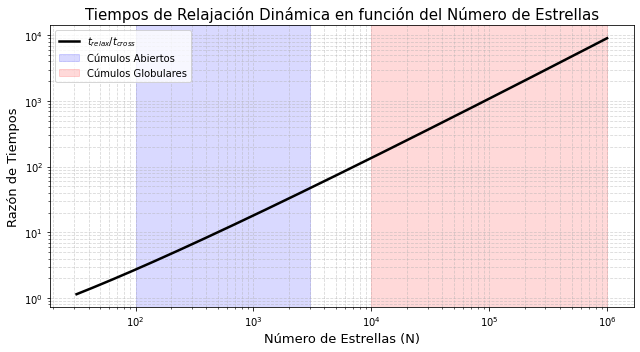

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = np.logspace(1.5, 6, 200)
t_relax_ratio = N / (8 * np.log(N))

plt.figure(figsize=(9, 5))
plt.plot(N, t_relax_ratio, 'k-', lw=2.5, label=r'$t_{relax} / t_{cross}$')
plt.axvspan(1e2, 3e3, color='blue', alpha=0.15, label='Cúmulos Abiertos')
plt.axvspan(1e4, 1e6, color='red', alpha=0.15, label='Cúmulos Globulares')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Número de Estrellas (N)', fontsize=13)
plt.ylabel('Razón de Tiempos', fontsize=13)
plt.title('Tiempos de Relajación Dinámica en función del Número de Estrellas', fontsize=15)
plt.legend(loc='upper left')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Equilibrio Dinámico y Equipartición de la Energía

Al transcurrir varios tiempos de relajación ($t > t_{relax}$), el intercambio constante de energía conduce al sistema a un estado de máximo desorden termodinámico.

### 3.1 Derivación Estadística: La Maximización de la Entropía
Modelamos la distribución de velocidades de las estrellas mediante una función de densidad de probabilidad $f(\mathbf{v})$. La entropía de Boltzmann es:

$$S = -k_B \int f(\mathbf{v}) \ln f(\mathbf{v}) \, d^3v$$

Maximizamos $S$ bajo la conservación del número de partículas ($N = \int f d^3v$) y la conservación de la energía cinética ($K = \int \frac{1}{2} m v^2 f d^3v$) utilizando **Multiplicadores de Lagrange**:

$$\delta \int \left[ -f \ln f - \lambda_1 f - \lambda_2 \left( \frac{1}{2} m v^2 f \right) \right] d^3v = 0$$

Derivando respecto a $f$ e igualando a cero:

$$-\ln f - 1 - \lambda_1 - \lambda_2 \frac{1}{2} m v^2 = 0 \implies f(\mathbf{v}) = \exp(-1 - \lambda_1) \exp\left( - \lambda_2 \frac{1}{2} m v^2 \right)$$

Definiendo $A = \exp(-1-\lambda_1)$ y usando la dispersión térmica $\sigma^2 = \frac{1}{\lambda_2 m} = \frac{k_B T}{m}$, e integrando sobre la cáscara esférica de velocidades ($d^3v = 4\pi v^2 dv$), demostramos formalmente la **Distribución de Maxwell-Boltzmann**:

$$f(v) \, dv = 4\pi A v^2 \exp\left( - \frac{v^2}{2 \sigma^2} \right) dv$$

### 3.2 El Principio de Equipartición
Los encuentros gravitacionales obligan al sistema a tender hacia una única "temperatura cinética":

$$\frac{1}{2} m_1 \sigma_1^2 = \frac{1}{2} m_2 \sigma_2^2 \implies \sigma(m) \propto m^{-0.5}$$

Predicción fundamental: las estrellas masivas se mueven más lento (segregación) y las ligeras adquieren altas velocidades.

### 3.3 Contraste Observacional: Cúmulos Abiertos vs. Globulares
*   **Caso 1: Cúmulo Abierto (Ej. Pléyades):** Siendo jóvenes (~115 Myr) y poco masivos, su $t_{relax}$ es de ~30 a 50 Myr. Se encuentran en un estado de **relajación parcial**. Al observarlos con Gaia, las estrellas masivas están termalizadas, pero la pendiente observada de $\sigma$ para estrellas de baja masa es más plana que -0.5. El campo de marea galáctico extrae a las estrellas rápidas antes de que alcancen la equipartición completa.
*   **Caso 2: Cúmulo Globular (Ej. NGC 2808):** Con edades > 10 Gyr y pozos de potencial profundos, han experimentado decenas de tiempos de relajación sin que la marea disuelva su núcleo. En este estado de **relajación profunda**, los datos del HST muestran un ajuste casi perfecto a la ley teórica $\sigma \propto m^{-0.5}$, evidenciando la firma intacta de la mecánica estadística clásica.

### 3.4 Taller Práctico Computacional: Extracción de Cinemática con ADQL
Este ejercicio instruye cómo calcular la dispersión de velocidades 3D y 1D real de las Pléyades utilizando minería de datos. Accedemos al archivo de Gaia a través del protocolo TAP y ejecutamos una consulta en SQL astronómico (ADQL) para transformar los movimientos propios ($\mu$) en velocidades transversales físicas ($v_{tan}$).

$$v_{tan} \approx 4.74 \frac{\mu}{\varpi}$$


Descargando datos de Gaia de forma síncrona con wget...


--2026-08-31 10:48:36--  https://gea.esac.esa.int/tap-server/tap/sync
Resolving gea.esac.esa.int (gea.esac.esa.int)... 193.147.152.106
Connecting to gea.esac.esa.int (gea.esac.esa.int)|193.147.152.106|:443... 

connected.


HTTP request sent, awaiting response... 

200 200
Length: unspecified [text/csv]
Saving to: 'pleiades_data.csv'

     0K .......... .......... .......... ..

........ ..........  133K
    50K .......... .......... .......... .......... ..........  272K
   100K .......... .......... .......

¡Descarga completada con éxito!

Miembros cinemáticos identificados: 1358
Dispersión de velocidad física (1D promedio): 0.99 km/s


... .......... ..........  276K
   150K .......... .......... .......... .......... .......... 8.84M
   200K .......... .......... ..........                       32.1M=0.7s

2026-08-31 10:48:48 (308 KB/s) - 'pleiades_data.csv' saved [235573]



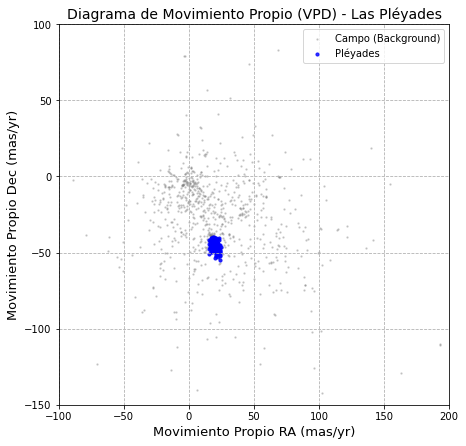

In [2]:
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir la consulta ADQL optimizada para las Pléyades
adql_query = """
SELECT source_id, ra, dec, parallax, pmra, pmdec
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 56.75, 24.11, 3.0))
  AND parallax BETWEEN 6.0 AND 9.0
  AND pmra IS NOT NULL AND pmdec IS NOT NULL
"""

# 2. Construir la URL del servicio TAP síncrono de la ESA y los parámetros
tap_url = "https://gea.esac.esa.int/tap-server/tap/sync"
payload = {
    'request': 'doQuery',
    'lang': 'adql',
    'format': 'csv',
    'query': adql_query
}

# 3. Descarga ultra-rápida utilizando wget mediante subprocess
import urllib.parse
encoded_payload = urllib.parse.urlencode(payload)
wget_command = [
    "wget",
    "--post-data", encoded_payload,
    "-O", "pleiades_data.csv",
    tap_url
]

print("Descargando datos de Gaia de forma síncrona con wget...")
subprocess.run(wget_command, check=True)
print("¡Descarga completada con éxito!")

# 4. Lectura inmediata del archivo de salida con Pandas
data = pd.read_csv("pleiades_data.csv")

# 5. Limpieza de datos (Filtro cinemático rústico para aislar el cúmulo)
mask = (data['pmra'] > 15) & (data['pmra'] < 25) & (data['pmdec'] > -55) & (data['pmdec'] < -40)
clean_data = data[mask]

# 6. Conversión de astrometría a velocidades tangenciales (km/s)
v_ra = 4.74 * (clean_data['pmra'] / clean_data['parallax'])
v_dec = 4.74 * (clean_data['pmdec'] / clean_data['parallax'])

sigma_ra = np.std(v_ra)
sigma_dec = np.std(v_dec)
sigma_1D = np.mean([sigma_ra, sigma_dec])

print(f"\nMiembros cinemáticos identificados: {len(clean_data)}")
print(f"Dispersión de velocidad física (1D promedio): {sigma_1D:.2f} km/s")

# 7. Visualización del Vector Point Diagram (VPD)
plt.figure(figsize=(7, 7))
plt.scatter(data['pmra'], data['pmdec'], s=2, c='gray', alpha=0.3, label='Campo (Background)')
plt.scatter(clean_data['pmra'], clean_data['pmdec'], s=10, c='blue', alpha=0.8, label='Pléyades')
plt.xlabel('Movimiento Propio RA (mas/yr)', fontsize=13)
plt.ylabel('Movimiento Propio Dec (mas/yr)', fontsize=13)
plt.title('Diagrama de Movimiento Propio (VPD) - Las Pléyades', fontsize=14)
plt.legend()
plt.xlim(-100, 200)
plt.ylim(-150, 100)
plt.grid(True, ls='--')
plt.show()

## 4. Artículos Relevantes Recomendados (Estado del Arte)

1. **Portegies Zwart, S. F., McMillan, S. L. W., & Gieles, M. (2010)**. *"Young Massive Star Clusters"*. Annual Review of Astronomy and Astrophysics, 48, 431-493.

    *Relevancia*: Es un artículo de revisión fundamental que conecta la formación de los cúmulos estelares con su evolución dinámica temprana. Aborda empíricamente cómo se miden los tiempos de cruce y relajación en poblaciones jóvenes, sirviendo de puente entre la hidrodinámica (Semana 2-3) y el régimen de N-cuerpos.

2. **Baumgardt, H., & Makino, J. (2003)**. *"Dynamical evolution of star clusters in tidal fields"*. Monthly Notices of the Royal Astronomical Society, 340(1), 227-246.

    *Relevancia*: Este es un trabajo teórico y computacional seminal. Mediante integradores directos de N-cuerpos, los autores demuestran cómo la interacción gravitacional interna (relajación) acoplada al campo de marea galáctico determina la tasa de evaporación del cúmulo. Vital para entender las limitaciones del Teorema del Virial en sistemas no aislados.

3. **Trenti, M., & van der Marel, R. (2013)**. *"Energy Equipartition in Globular Clusters"*. Monthly Notices of the Royal Astronomical Society, 435(4), 3272-3282.

    *Relevancia*: Aterriza de forma crítica la teoría de la maximización de la entropía. Demuestra, usando simulaciones de N-cuerpos y comparaciones observacionales, por qué los cúmulos reales nunca alcanzan una equipartición perfecta de energía ($\sigma \propto m^{−0.5}$) debido al escape constante de estrellas de baja masa y la inestabilidad termodinámica.

4. **Cantat-Gaudin, T., et al. (2018)**. *"A Gaia DR2 view of the open cluster population in the Milky Way"*. Astronomy & Astrophysics, 618, A93.

    *Relevancia*: Muestra la aplicación de vanguardia del análisis de movimientos propios y paralajes astronómicos. Detalla la metodología observacional para identificar miembros de cúmulos estelares utilizando algoritmos de aprendizaje automático no supervisado (DBSCAN), enlazando directamente con la lógica del taller práctico de ADQL y astrometría propuesto en clase.

5. **Meingast, S., & Alves, J. (2019)**. *"Extended stellar systems in the solar neighborhood. II. Discovery of a massive tail associated with the Pleiades"*. Astronomy & Astrophysics, 627, A66.


    *Relevancia*: Presenta evidencia observacional directa y reciente de la evaporación estelar y la segregación. Los autores cartografían una gigantesca "cola de marea" escapando de las Pléyades, ilustrando de manera espectacular cómo el intercambio de energía cinética predicho por las ecuaciones de relajación disuelve los cúmulos abiertos en el campo galáctico.

## 5. Ejercicios Propuestos

**Ejercicio 1 (Analítico):**
Derive la expresión de la Masa Virial ($M_{vir} = \frac{3 \sigma^2 R_v}{G}$) asumiendo un cúmulo esférico isotrópico. Calcule la masa para un cúmulo con dispersión observada de 2.5 km/s y radio virial de 3 pc.

**Ejercicio 2 (Analítico):**
Asumiendo equipartición de energía en un cúmulo, si las estrellas de tipo solar (1.0 $M_\odot$) muestran una dispersión de velocidades 3D de 12 km/s, ¿cuál debe ser la dispersión teórica para una población de enanas blancas masivas (1.4 $M_\odot$)?

**Ejercicio 3 (Computacional / Data Mining con ADQL):**
Modifique el script en Python de la Sección 3.4. Ejecute una consulta ADQL para el cúmulo de las Hyades ($\alpha \approx 66.75^\circ$, $\delta \approx 15.86^\circ$), aislando el paralaje correcto (~21 mas). Calcule la dispersión de velocidades en la dirección de la Ascensión Recta ($\sigma_{v\_ra}$).

In [3]:
from IPython.display import IFrame
IFrame(src="https://youtube.com/shorts/_J8Hj4qGN6A", width="100%", height="500px")

In [4]:
from IPython.display import IFrame
IFrame(src="https://www.youtube.com/embed/bzbRL4PBG3U", width="100%", height="500px")

In [5]:
from IPython.display import IFrame
IFrame(src="https://www.youtube.com/embed/pYaXknkC_Eo", width="100%", height="500px")

In [6]:
## Escriba aquí su solución